In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

orders = pd.read_csv("datasets/processed_orders.csv")

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Sales per Unit,Cost per Unit,Distance Category,High Value Order,Route ID,Shipping Rate ($/km),Estimated Shipping Cost,Delivery Efficiency Score,Factory Order Count,Factory Workload
0,1,ORD00001,2025-02-07,2025-02-08,1,CUST9313,USA,Houston,TX,38140,...,2.69,1.74,2,1,Sugar Shack_South,1.1,326.7,297.0,1676,0
1,2,ORD00002,2025-05-04,2025-05-05,1,CUST3028,USA,Chicago,IL,39260,...,3.56,2.88,2,0,Lot's O' Nuts_Central,1.1,424.6,386.0,996,0
2,3,ORD00003,2025-04-24,2025-04-25,1,CUST7867,USA,New York,NY,28907,...,3.70,2.89,2,0,Secret Factory_East,1.1,333.3,303.0,977,2
3,4,ORD00004,2025-10-25,2025-10-29,2,CUST2028,USA,Los Angeles,CA,83972,...,3.72,2.43,1,0,Lot's O' Nuts_West,0.6,313.2,130.5,996,0
4,5,ORD00005,2025-08-07,2025-08-12,1,CUST6924,USA,Houston,TX,49291,...,4.67,2.66,3,1,Sugar Shack_South,1.1,2504.7,455.4,1676,0


In [3]:
cluster_features = [
    "Distance (km)",
    "Lead Time",
    "Estimated Shipping Cost",
    "Division",
    "Region",
    "Factory"
]

In [4]:
label_columns = [
    "Division",
    "Region",
    "Factory"
]

encoders = {}

for col in label_columns:

    le = LabelEncoder()

    orders[col] = le.fit_transform(orders[col])

    encoders[col] = le

In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(
    orders[cluster_features]
)

print(X.shape)

(5000, 6)


In [6]:
# ==========================================================
# Elbow Method
# ==========================================================

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

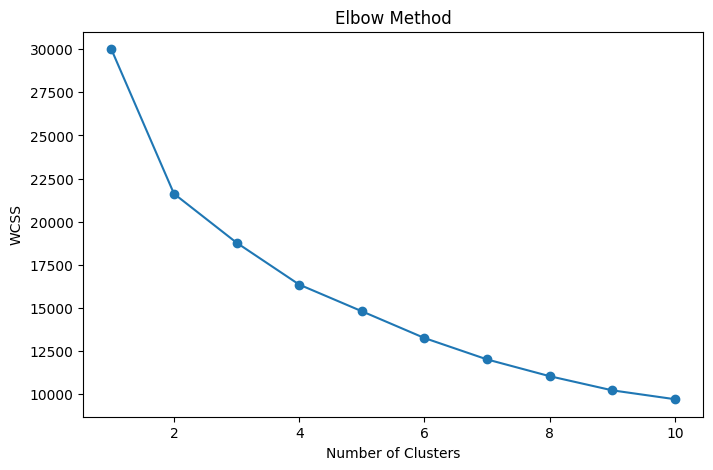

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

orders["Cluster"] = kmeans.fit_predict(X)

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Cost per Unit,Distance Category,High Value Order,Route ID,Shipping Rate ($/km),Estimated Shipping Cost,Delivery Efficiency Score,Factory Order Count,Factory Workload,Cluster
0,1,ORD00001,2025-02-07,2025-02-08,1,CUST9313,USA,Houston,TX,38140,...,1.74,2,1,Sugar Shack_South,1.1,326.7,297.0,1676,0,1
1,2,ORD00002,2025-05-04,2025-05-05,1,CUST3028,USA,Chicago,IL,39260,...,2.88,2,0,Lot's O' Nuts_Central,1.1,424.6,386.0,996,0,0
2,3,ORD00003,2025-04-24,2025-04-25,1,CUST7867,USA,New York,NY,28907,...,2.89,2,0,Secret Factory_East,1.1,333.3,303.0,977,2,1
3,4,ORD00004,2025-10-25,2025-10-29,2,CUST2028,USA,Los Angeles,CA,83972,...,2.43,1,0,Lot's O' Nuts_West,0.6,313.2,130.5,996,0,0
4,5,ORD00005,2025-08-07,2025-08-12,1,CUST6924,USA,Houston,TX,49291,...,2.66,3,1,Sugar Shack_South,1.1,2504.7,455.4,1676,0,3


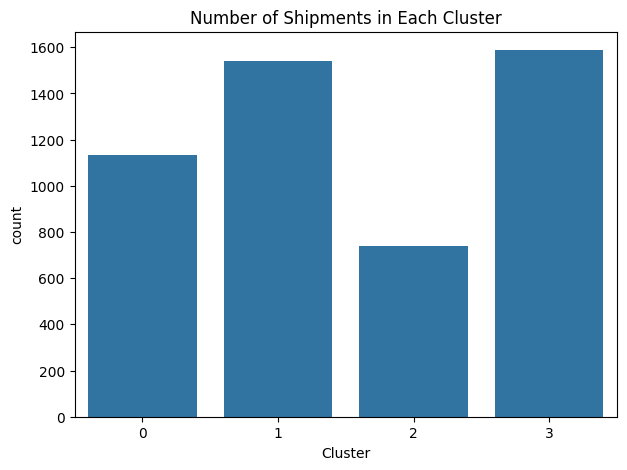

Cluster
3    1588
1    1541
0    1133
2     738
Name: count, dtype: int64

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=orders,
    x="Cluster"
)

plt.title("Number of Shipments in Each Cluster")

plt.show()

orders["Cluster"].value_counts()

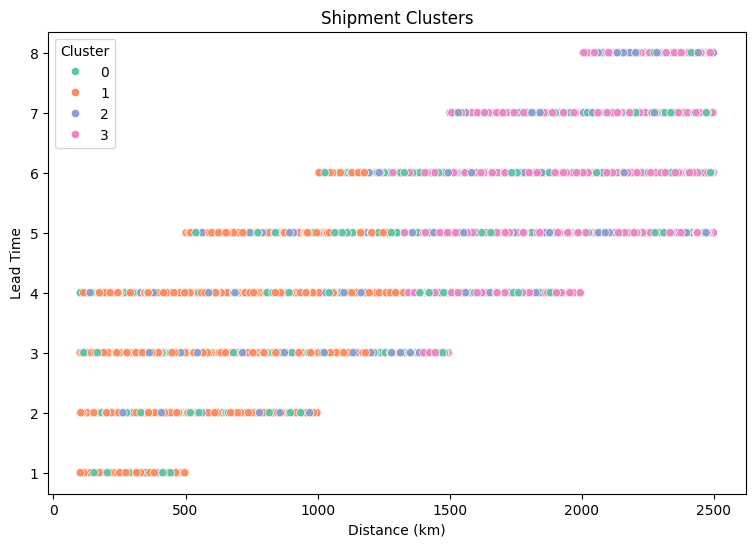

In [10]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=orders,
    x="Distance (km)",
    y="Lead Time",
    hue="Cluster",
    palette="Set2"
)

plt.title("Shipment Clusters")

plt.show()

In [11]:
cluster_summary = orders.groupby("Cluster")[[
    "Distance (km)",
    "Lead Time",
    "Estimated Shipping Cost",
    "Sales",
    "Gross Profit"
]].mean()

cluster_summary

,Distance (km),Lead Time,Estimated Shipping Cost,Sales,Gross Profit
Cluster,,,,,
0,1287.647838,4.564872,951.035658,655.439100,220.519250
1,670.646982,3.290720,508.037378,652.486807,218.970337
2,1282.533875,4.638211,927.541734,622.203699,206.071287
3,1924.404912,5.833753,1419.233659,622.688130,207.785730


In [12]:
cluster_size = orders.groupby("Cluster").size().reset_index(name="Number of Shipments")

cluster_size

,Cluster,Number of Shipments
0,0,1133
1,1,1541
2,2,738
3,3,1588
